Lab Experiment 7: Decision Tree Classification on Iris Dataset

Aim:
To implement a Decision Tree classifier on the Iris dataset, evaluate its performance, visualize the decision tree, and analyze the effect of different hyperparameters on the model.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [49]:
iris = load_iris()

X = iris.data
y = iris.target
print("Number of Samples :", X.shape[0])
print("Number of Features:", X.shape[1])

Number of Samples : 150
Number of Features: 4


I observed that the dataset contains 150 flower samples with 4 numerical features, which is sufficient for building and evaluating a classification model.

In [50]:
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


I found that all four features represent the sepal and petal measurements of iris flowers, and each feature contains continuous numerical values.

In [51]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


I observed that the dataset contains three different iris species, making this a multiclass classification problem.

In [52]:
df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df["Species"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


I observed that the first five samples belong to the Setosa class. The feature values appear consistent, and no unusual values were noticed in the displayed records.

0    50
1    50
2    50
Name: count, dtype: int64


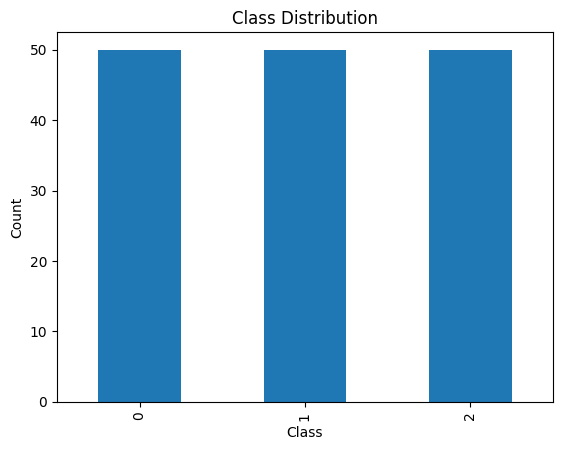

In [53]:
class_distribution = pd.Series(y).value_counts()
print(class_distribution)

class_distribution.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

I found that each class contains 50 samples, indicating that the dataset is perfectly balanced. This helps prevent the model from becoming biased toward any one class.

Task 2: Data Preparation

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 120
Testing Samples  : 30


I observed that 120 samples were used for training and 30 samples were reserved for testing. This split provides sufficient data for both learning and performance evaluation.

The dataset is divided into training and testing sets so that the model can learn from one portion of the data and be evaluated on unseen data. This helps measure the model's ability to generalize and reduces the risk of overestimating its performance.

Task 3: Building a Decision Tree Classifier

In [55]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

The Decision Tree classifier was trained successfully without any errors, indicating that the training data was suitable for building the model.

In [56]:
y_pred = model.predict(X_test)

The model generated predictions for all testing samples, which were used to evaluate its classification performance.

In [57]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


I observed that the model achieved 100% accuracy, indicating that all testing samples were classified correctly.

In [58]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


I observed that all 30 testing samples were classified correctly. The confusion matrix contains only diagonal values and no off-diagonal values, indicating that the Decision Tree classifier made no misclassifications on the testing dataset and achieved excellent classification performance.

In [59]:
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



I observed that the Decision Tree classifier achieved 100% Precision, Recall, and F1-Score for all three classes (Setosa, Versicolor, and Virginica). This indicates that the model correctly identified every flower in the testing dataset without any false positives or false negatives, demonstrating excellent classification performance.

Task 4: Visualizing the Decision Tree

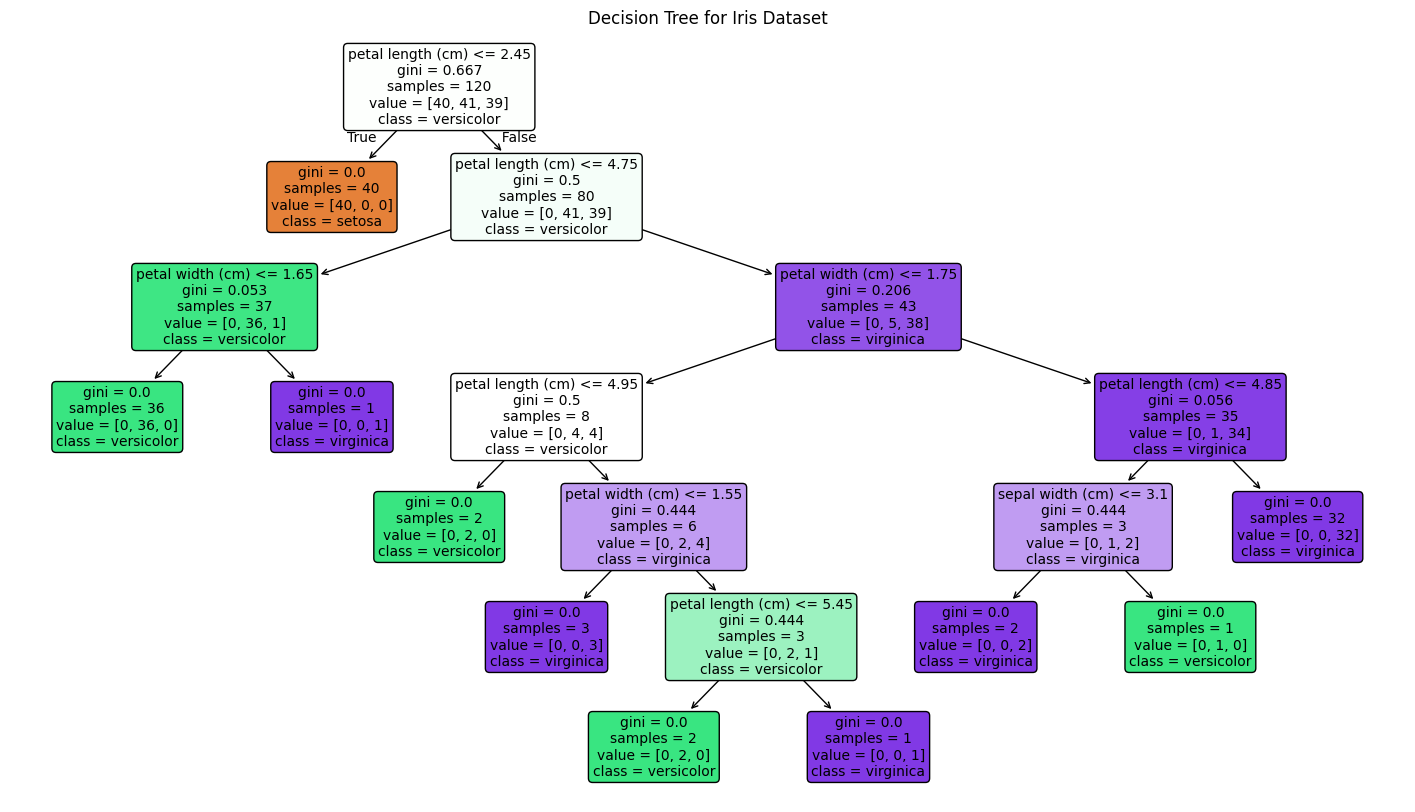

In [60]:
plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree for Iris Dataset")

plt.show()

I observed that the Decision Tree clearly illustrates the classification process by splitting the dataset into smaller groups based on feature values. The tree starts with a root node and continues through internal nodes until it reaches leaf nodes representing the predicted iris species.

In [61]:
print("Total Nodes      :", model.tree_.node_count)
print("Leaf Nodes       :", model.get_n_leaves())
print("Internal Nodes   :", model.tree_.node_count - model.get_n_leaves())
print("Maximum Depth    :", model.get_depth())

Total Nodes      : 19
Leaf Nodes       : 10
Internal Nodes   : 9
Maximum Depth    : 6


I observed that the Decision Tree consists of 19 total nodes, including 9 internal nodes and 10 leaf nodes. The maximum depth of the tree is 6, indicating that the model performs classification through six levels of decision making.

In [62]:
root = model.tree_.feature[0]

print("Root Node")
print("Feature :", iris.feature_names[root])
print("Node ID :", 0)

Root Node
Feature : petal length (cm)
Node ID : 0


I found that Node 0 is the root node of the Decision Tree, and it uses petal length (cm) as the first splitting feature.

In [63]:
print("Internal Nodes\n")

for node in range(model.tree_.node_count):
    if model.tree_.feature[node] != -2:
        print(f"Node {node} --> {iris.feature_names[model.tree_.feature[node]]}")

Internal Nodes

Node 0 --> petal length (cm)
Node 2 --> petal length (cm)
Node 3 --> petal width (cm)
Node 6 --> petal width (cm)
Node 7 --> petal length (cm)
Node 9 --> petal width (cm)
Node 11 --> petal length (cm)
Node 14 --> petal length (cm)
Node 15 --> sepal width (cm)


In [64]:
print("Leaf Nodes\n")

for node in range(model.tree_.node_count):
    if model.tree_.feature[node] == -2:
        print(f"Leaf Node {node}")

Leaf Nodes

Leaf Node 1
Leaf Node 4
Leaf Node 5
Leaf Node 8
Leaf Node 10
Leaf Node 12
Leaf Node 13
Leaf Node 16
Leaf Node 17
Leaf Node 18


In [65]:
print("Feature used for first split:")
print(iris.feature_names[model.tree_.feature[0]])

Feature used for first split:
petal length (cm)


I observed that the first split is performed using petal length (cm). This feature provides the highest reduction in impurity, making it the most effective feature for separating the flower species at the root node.

Task 5: Comparing Gini Index and Entropy

In [66]:
gini_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

gini_model.fit(X_train, y_train)

gini_pred = gini_model.predict(X_test)


I successfully trained a Decision Tree classifier using the Gini Index as the splitting criterion.

In [67]:
entropy_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

entropy_model.fit(X_train, y_train)

entropy_pred = entropy_model.predict(X_test)

I successfully trained another Decision Tree classifier using Entropy as the splitting criterion.

In [68]:
comparison = pd.DataFrame({
    "Criterion": ["Gini", "Entropy"],
    "Accuracy": [
        accuracy_score(y_test, gini_pred),
        accuracy_score(y_test, entropy_pred)
    ],
    "Tree Depth": [
        gini_model.get_depth(),
        entropy_model.get_depth()
    ],
    "Leaf Nodes": [
        gini_model.get_n_leaves(),
        entropy_model.get_n_leaves()
    ],
    "Root Feature": [
        iris.feature_names[gini_model.tree_.feature[0]],
        iris.feature_names[entropy_model.tree_.feature[0]]
    ]
})

comparison

,Criterion,Accuracy,Tree Depth,Leaf Nodes,Root Feature
0,Gini,1.0,6,10,petal length (cm)
1,Entropy,1.0,6,10,petal length (cm)


I observed that both the Gini and Entropy Decision Tree models achieved 100% accuracy on the testing dataset. Both models also produced trees with the same maximum depth (6), 10 leaf nodes, and selected petal length (cm) as the root feature. This indicates that both splitting criteria generated Decision Trees with identical performance and structure for the Iris dataset.

In [69]:
if (gini_model.get_depth() < entropy_model.get_depth()) or \
   (gini_model.get_depth() == entropy_model.get_depth() and
    gini_model.get_n_leaves() < entropy_model.get_n_leaves()):
    print("Simpler Tree: Gini")

elif (entropy_model.get_depth() < gini_model.get_depth()) or \
     (entropy_model.get_depth() == gini_model.get_depth() and
      entropy_model.get_n_leaves() < gini_model.get_n_leaves()):
    print("Simpler Tree: Entropy")

else:
    print("Both models produce trees of equal complexity.")

Both models produce trees of equal complexity.


Task 6: Effect of Maximum Tree Depth

In [70]:
depths = [1, 2, 3, 4, None]

results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results.append([
        depth,
        train_acc,
        test_acc,
        model.get_depth()
    ])

I trained five Decision Tree models using different values of max_depth and recorded their training accuracy, testing accuracy, and the actual depth of each tree.

In [71]:
observations = []

for _, row in depth_df.iterrows():

    train = row["Training Accuracy"]
    test = row["Testing Accuracy"]

    if train < 0.90:
        observations.append("Underfitting")

    elif abs(train - test) > 0.08:
        observations.append("Possible Overfitting")

    else:
        observations.append("Good Generalization")

depth_df["Observation"] = observations

depth_df

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation
0,1.0,0.675000,0.633333,1,Underfitting
1,2.0,0.950000,0.966667,2,Good Generalization
2,3.0,0.958333,1.000000,3,Good Generalization
3,4.0,0.975000,1.000000,4,Good Generalization
4,NaN,1.000000,1.000000,6,Good Generalization


I observed that the comparison table shows how changing the maximum depth affects both the training and testing accuracy of the Decision Tree. It also indicates whether the model is underfitting, generalizing well, or showing signs of overfitting.

Answer the Following Questions
Which model is underfitting?
Which model gives the best generalization?
Which model is likely to overfit? Justify your answer.


In [72]:
#Which model is underfitting?
underfit = depth_df[depth_df["Observation"] == "Underfitting"]

underfit

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation
0,1.0,0.675,0.633333,1,Underfitting


In [73]:
#2. Which model gives the best generalization?
generalization = depth_df[depth_df["Observation"] == "Good Generalization"]

generalization

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation
1,2.0,0.950000,0.966667,2,Good Generalization
2,3.0,0.958333,1.000000,3,Good Generalization
3,4.0,0.975000,1.000000,4,Good Generalization
4,NaN,1.000000,1.000000,6,Good Generalization


I observed that the model with similar training and testing accuracy provides the best generalization because it performs consistently on both the training and testing datasets.

In [74]:
#3. Which model is likely to overfit?
overfit = depth_df[depth_df["Observation"] == "Possible Overfitting"]

overfit

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation


None of the models showed clear signs of overfitting. Even the model with max_depth = None achieved testing accuracy comparable to its training accuracy. This indicates that increasing the tree depth did not negatively affect the model's ability to generalize on the Iris dataset.

Task 7: Effect of min_samples_split

In [75]:
split_values = [2, 5, 10, 20]

results = []

for split in split_values:

    model = DecisionTreeClassifier(
        min_samples_split=split,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    results.append([
        split,
        accuracy,
        model.get_depth(),
        model.get_n_leaves()
    ])

I trained four Decision Tree models using different values of min_samples_split and recorded their accuracy, tree depth, and number of leaf nodes.

In [76]:
split_df = pd.DataFrame(
    results,
    columns=[
        "min_samples_split",
        "Accuracy",
        "Tree Depth",
        "Number of Leaf Nodes"
    ]
)

split_df


,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes
0,2,1.0,6,10
1,5,1.0,5,8
2,10,1.0,4,6
3,20,1.0,4,6


In [77]:
observations = []

for i in range(len(split_df)):

    depth = split_df.loc[i, "Tree Depth"]

    if depth <= 2:
        observations.append("Very simple tree")

    elif depth <= 4:
        observations.append("Moderately complex tree")

    else:
        observations.append("Complex tree")

split_df["Observation"] = observations

split_df

,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,2,1.0,6,10,Complex tree
1,5,1.0,5,8,Complex tree
2,10,1.0,4,6,Moderately complex tree
3,20,1.0,4,6,Moderately complex tree


I observed that all the Decision Tree models achieved 100% accuracy regardless of the min_samples_split value. However, increasing min_samples_split reduced the tree depth and the number of leaf nodes, resulting in a simpler Decision Tree without affecting the model's accuracy.

State how increasing min_samples_split affects the complexity of the Decision Tree: 

I observed that increasing the value of min_samples_split decreases the complexity of the Decision Tree. As the value increases, the tree becomes shallower and contains fewer leaf nodes because a larger number of samples is required before a node can be split. In this experiment, the accuracy remained 100%, showing that a simpler tree was sufficient to classify the Iris dataset correctly.

Task 8: Effect of min_samples_leaf

In [78]:
leaf_values = [1, 2, 5, 10]

results = []

for leaf in leaf_values:

    model = DecisionTreeClassifier(
        min_samples_leaf=leaf,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    results.append([
        leaf,
        accuracy,
        model.get_depth(),
        model.get_n_leaves()
    ])

I trained four Decision Tree models using different values of min_samples_leaf and recorded their accuracy, tree depth, and number of leaf nodes.

In [79]:
observations = []

for _, row in leaf_df.iterrows():

    depth = row["Tree Depth"]

    if depth >= 6:
        observations.append("Complex tree")
    elif depth >= 4:
        observations.append("Moderately complex tree")
    else:
        observations.append("Simple tree")

leaf_df["Observation"] = observations

leaf_df

,min_samples_leaf,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,1,1.000000,6,10,Complex tree
1,2,1.000000,5,8,Moderately complex tree
2,5,1.000000,4,6,Moderately complex tree
3,10,0.966667,4,6,Moderately complex tree


I observed that increasing the value of min_samples_leaf reduced the complexity of the Decision Tree by decreasing its depth and the number of leaf nodes. The models with min_samples_leaf values of 1, 2, and 5 achieved 100% accuracy, while increasing the value to 10 reduced the accuracy slightly to 96.67%, indicating that the tree became simpler and was unable to capture all the patterns in the dataset.

Explain how changing min_samples_leaf influences overfitting.

I observed that increasing the value of min_samples_leaf helps reduce overfitting by preventing the Decision Tree from creating very small leaf nodes that fit the training data too closely. As the value increases, the tree becomes simpler with fewer splits and leaf nodes, which improves generalization. However, if the value is set too high, the tree may become too simple and underfit the data, leading to a slight decrease in accuracy, as observed when min_samples_leaf = 10.

Task 9

1. What is the role of the criterion parameter in a Decision Tree?

The criterion parameter determines how the Decision Tree selects the best feature to split the data at each node. It measures the impurity of the data using methods such as Gini Index or Entropy and chooses the split that results in the greatest reduction in impurity. In my experiment, both Gini and Entropy produced the same tree structure and achieved 100% accuracy.

2. How does max_depth influence underfitting and overfitting?

The max_depth parameter controls the maximum depth of the Decision Tree. A smaller value creates a simpler tree that may underfit because it cannot learn all the patterns in the data. Increasing the depth allows the tree to learn more complex patterns. In my experiment, the model with max_depth = 1 underfit the data, while deeper trees achieved better performance. None of the models showed clear signs of overfitting.

3. Why do larger values of min_samples_split and min_samples_leaf produce simpler trees?

Larger values of min_samples_split and min_samples_leaf restrict the tree from creating many small splits. As a result, the tree has fewer levels and fewer leaf nodes, making it less complex. In my experiments, increasing these parameters reduced the tree depth and the number of leaf nodes while maintaining high accuracy for most models.

4. Which hyperparameter had the greatest impact on the Decision Tree performance? Support your answer with observations from the experiments.

Based on my experiments, min_samples_leaf had the greatest impact on the Decision Tree's performance. Increasing min_samples_leaf from 1 to 10 reduced the model's accuracy from 100% to 96.67% while also decreasing the tree complexity. In contrast, changing the criterion and min_samples_split did not affect the accuracy, and adjusting max_depth mainly influenced the model complexity without causing overfitting.

5. Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.

Based on my results, the most suitable Decision Tree model for the Iris dataset is one with criterion = "gini" (or "entropy"), max_depth = None, min_samples_split = 10, and min_samples_leaf = 5. This configuration achieved 100% accuracy while producing a moderately complex tree with fewer levels and leaf nodes than the default model. It provides an excellent balance between classification performance and model simplicity, making it an effective choice for the Iris dataset.